# 12 - Explainability del ramo prosodico su ASVspoof 2021 DF


In [1]:
import os, json, math, time, hashlib, importlib.util, urllib.request
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, bootstrap


# --------------------------------------------------------------------------------
# PERCORSI - le uniche righe da adattare
OUT_DIR   = Path(os.environ.get("OUT_DIR", "/kaggle/working/df2021"))   # output del notebook 11
ANA_DIR   = Path(os.environ.get("ANA_DIR", "/kaggle/working/explain"))  # output di questo notebook

# blocchi prosodici: stesse due cartelle usate in inferenza dal notebook 11
PROS_DIR       = Path("/kaggle/input/datasets/angelopaldino/features/results_Prosodia/df2021/prosodia")
PROS_DIR_EXTRA = Path("/kaggle/input/datasets/angelo01paldino/prosodia-extra/df2021/prosodia_extra")

# indice e punteggi prodotti dal notebook 11
INDEX_PATH = Path("/kaggle/input/datasets/angelo01paldino/prosodia-extra/df2021/index_df.csv")
SCORES_DIR = "/kaggle/input/datasets/angelo01paldino/scores_extra/scores"
SCORES_FMT = "scores_df_{}.npy"

# necessari solo per le sezioni 4 e 5
CKPT_P           = "/kaggle/input/datasets/angelopaldino/models/Modelli/model_D_seed0.pt"
PREPROC_PROSODIA = "/kaggle/input/datasets/angelopaldino/models/Modelli/preproc_prosody.json"
# --------------------------------------------------------------------------------

NOMI = ["P", "Wf", "E", "PWfE"]
FEATURES = ["f0_mean", "f0_std", "jitter_local", "shimmer_local",
            "hnr_mean", "hnr_std", "intensity_mean", "intensity_std"]
UNITA = ["Hz", "Hz", "-", "-", "dB", "dB", "dB", "dB"]
EMB_DIM, DROPOUT, EVAL_BATCH = 50, 0.2, 256
MIN_PER_CLASSE = 10            # sotto questa soglia un EER di gruppo non viene calcolato
N_BOOT = 1000                  # ricampionamenti per gli intervalli di confidenza
SEED = 0

ANA_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 150, "font.size": 10})
print("output in", ANA_DIR)

output in /kaggle/working/explain


In [2]:
# Metrica ufficiale ASVspoof 2021, identica ai notebook 06.1, 09, 10 e 11.
EVAL_METRICS_URL = "https://raw.githubusercontent.com/asvspoof-challenge/2021/main/eval-package/eval_metrics.py"
EVAL_METRICS_PATH = ANA_DIR / "eval_metrics.py"
if not EVAL_METRICS_PATH.exists():
    urllib.request.urlretrieve(EVAL_METRICS_URL, EVAL_METRICS_PATH)
spec = importlib.util.spec_from_file_location("asvspoof_eval_metrics", EVAL_METRICS_PATH)
asv_metrics = importlib.util.module_from_spec(spec); spec.loader.exec_module(asv_metrics)
EVAL_METRICS_SHA256 = hashlib.sha256(EVAL_METRICS_PATH.read_bytes()).hexdigest()
assert EVAL_METRICS_SHA256.startswith("70c5d2fe8fab6654"), \
    f"eval_metrics.py inatteso: {EVAL_METRICS_SHA256[:16]}"
print("eval_metrics.py | sha256", EVAL_METRICS_SHA256[:16], "...")


def _eer(pos, neg):
    """EER grezzo, senza soglia minima. Punteggio alto = classe positiva."""
    return float(asv_metrics.compute_eer(np.asarray(pos, dtype=np.float64),
                                         np.asarray(neg, dtype=np.float64))[0])


def eer_da_insiemi(pos, neg):
    """Come _eer, ma restituisce NaN se un gruppo ha meno di MIN_PER_CLASSE elementi."""
    if min(len(pos), len(neg)) < MIN_PER_CLASSE:
        return np.nan
    return _eer(pos, neg)


def compute_eer(y, s):
    """EER con convenzione y == 1 -> bona fide (positivo), con soglia minima."""
    y, s = np.asarray(y), np.asarray(s, dtype=np.float64)
    return eer_da_insiemi(s[y == 1], s[y == 0])


def soglia_eer(y, s):
    """Soglia alla quale P_miss = P_fa, dalla curva DET ufficiale."""
    s = np.asarray(s, dtype=np.float64)
    frr, far, thr = asv_metrics.compute_det_curve(s[y == 1], s[y == 0])
    i = int(np.argmin(np.abs(frr - far)))
    return float(thr[i]), float(frr[i]), float(far[i])


def ic95(v, n_boot=N_BOOT, seed=SEED):
    """IC 95% della media con scipy.stats.bootstrap (metodo percentile).

    `batch` limita la memoria: senza, il ricampionamento allocherebbe una matrice
    n_resamples x len(v), che su gruppi da centinaia di migliaia di file supera i GB.
    """
    v = np.asarray(v, dtype=np.float64)
    v = v[np.isfinite(v)]
    if len(v) < 2 or np.ptp(v) == 0:
        return (float(v.mean()), float(v.mean())) if len(v) else (np.nan, np.nan)
    r = bootstrap((v,), np.mean, confidence_level=0.95, n_resamples=n_boot,
                  method="percentile", batch=max(1, int(2e7 // len(v))),
                  random_state=np.random.default_rng(seed))
    return (float(r.confidence_interval.low), float(r.confidence_interval.high))


# controlli sulle definizioni: separazione perfetta -> 0, ordine invertito -> 1
assert _eer([2.0, 3.0], [0.0, 1.0]) == 0.0
assert _eer([0.0, 1.0], [2.0, 3.0]) == 1.0
assert np.isnan(eer_da_insiemi([1.0, 2.0], [0.0, 3.0])), "la soglia MIN_PER_CLASSE non scatta"

eval_metrics.py | sha256 70c5d2fe8fab6654 ...


In [4]:
import numpy as np


index = pd.read_csv(INDEX_PATH, dtype=str)
index["y_bonafide"] = index["y_bonafide"].astype(np.int8)
Y = index["y_bonafide"].to_numpy().astype(np.int8)
UTT = index["utt_id"].to_numpy()
POS = {u: i for i, u in enumerate(UTT)}
N = len(index)
assert len(POS) == N, "utt_id duplicati nell'indice"

def trova_punteggi(dir_iniziale):
    """Cerca la cartella con i quattro scores_df_*.npy.

    Prima dove indicato; se non c'e', esplora l'albero Kaggle fino a sei livelli
    (senza scendere nelle cartelle degli audio, che renderebbero la ricerca lentissima).
    """
    d = Path(dir_iniziale)
    if d.exists() and (d / SCORES_FMT.format("P")).exists():
        return d
    trovate = set()
    for radice in [Path("/kaggle/input"), Path("/kaggle/working"), OUT_DIR.parent]:
        if not radice.exists():
            continue
        for prof in range(0, 7):
            modello_glob = "/".join(["*"] * prof + [SCORES_FMT.format("P")])
            trovate.update(p.parent for p in radice.glob(modello_glob))
    trovate = sorted(trovate)
    if len(trovate) == 1:
        print(f"ATTENZIONE: {SCORES_FMT.format('P')} non presente in {d}\n"
              f"            individuato automaticamente in {trovate[0]}")
        return trovate[0]
    if len(trovate) > 1:
        raise FileNotFoundError(
            "Piu' cartelle contengono i punteggi. Imposta SCORES_DIR a una di queste:\n"
            + "\n".join(f"   {c}" for c in trovate))
    raise FileNotFoundError(
        f"Nessun {SCORES_FMT.format('P')} sotto /kaggle/input o /kaggle/working.\n"
        f"Carica come dataset l'output del notebook 11 (i quattro scores_df_*.npy) "
        f"e imposta SCORES_DIR, oppure riesegui la fase 'inferenza' del notebook 11.")


SCORES_DIR = "/kaggle/input/datasets/angelo01paldino/scores-extra/scores"

SCORES, assenti = {}, []
for n in NOMI:
    p = Path(SCORES_DIR) / SCORES_FMT.format(n)
    if not p.exists():
        assenti.append(p.name)
        continue
    s = np.load(p)
    assert len(s) == N, (
        f"{n}: {len(s):,} punteggi contro {N:,} prove nell'indice. "
        f"Punteggi e index_df.csv devono venire dalla STESSA esecuzione del notebook 11: "
        f"533.928 corrisponde alla run sul solo 'eval', 611.829 a quella sui tre sottoinsiemi.")
    assert np.isfinite(s).all(), f"{n}: punteggi non finiti"
    SCORES[n] = s.astype(np.float64)
NOMI = [n for n in NOMI if n in SCORES]
if assenti:
    print(f"ATTENZIONE: non trovati {assenti}: configurazioni escluse dall'analisi")
assert NOMI, f"nessun file di punteggi leggibile in {SCORES_DIR}"

SRC = index["source"].to_numpy()
SUB = index["subset"].to_numpy()
COD = index["codec"].to_numpy()
SORGENTI = sorted(pd.unique(SRC))
SOTTOINSIEMI = [s for s in ["eval", "progress", "hidden"] if s in set(SUB)]

print(f"{N:,} prove | bona fide {int(Y.sum()):,} | spoof {int((1 - Y).sum()):,}")
print("configurazioni:", NOMI)
print("sorgenti:", SORGENTI, "| sottoinsiemi:", SOTTOINSIEMI)

# riproduzione degli EER gia' noti: se non coincidono, i file non sono quelli attesi
rip = pd.DataFrame([{"configurazione": n, "eer_%": round(100 * compute_eer(Y, SCORES[n]), 2)}
                    for n in NOMI]).set_index("configurazione")
print("\n=== EER complessivo, ricalcolato dai punteggi salvati ===")
display(rip)

611,829 prove | bona fide 22,617 | spoof 589,212
configurazioni: ['P', 'Wf', 'E', 'PWfE']
sorgenti: ['asvspoof', 'vcc2018', 'vcc2020'] | sottoinsiemi: ['eval', 'progress', 'hidden']

=== EER complessivo, ricalcolato dai punteggi salvati ===


,eer_%
configurazione,
P,26.17
Wf,13.31
E,21.41
PWfE,16.02


## Sezione 1 - Quanto silenzio c'e' nel DF

Per ogni file si calcolano quattro quantita' dalle caratteristiche Praat **grezze**, prima di
qualunque trasformazione:

- $T_i$: numero di finestre da 200 ms;
- $\varphi_i$: frazione di finestre mute;
- $\varphi^{\text{lead}}_i$: lunghezza della corsa iniziale di finestre mute, divisa per $T_i$;
- $\varphi^{\text{trail}}_i$: lunghezza della corsa finale, divisa per $T_i$.


In [5]:
def corse_bordo(mute):
    """Lunghezza della corsa iniziale e finale di True in un vettore booleano."""
    T = len(mute)
    if T == 0:
        return 0, 0
    if mute.all():
        return T, 0                       # tutto muto: attribuito alla corsa iniziale
    if not mute.any():
        return 0, 0
    return int(np.argmax(~mute)), int(np.argmax(~mute[::-1]))


shards = sorted(PROS_DIR.glob("pros_*.npz")) + sorted(PROS_DIR_EXTRA.glob("pros_*.npz"))
assert shards, f"nessun blocco prosodico in {PROS_DIR} ne' in {PROS_DIR_EXTRA}"
print(f"{len(shards)} blocchi prosodici")

T_W    = np.full(N, -1, dtype=np.int32)      # finestre per file
PHI    = np.full(N, np.nan, dtype=np.float64)
PHI_L  = np.full(N, np.nan, dtype=np.float64)
PHI_T  = np.full(N, np.nan, dtype=np.float64)
n_err_praat = 0

t0 = time.perf_counter()
for k, p in enumerate(shards):
    z = np.load(p, allow_pickle=True)
    X, off, utt = z["X"], z["offsets"].astype(np.int64), z["utt_id"]
    if "error" in z:
        n_err_praat += int((z["error"] != "").sum())
    mute_tutto = (np.abs(X).sum(1) == 0)      # vettorizzato sull'intero blocco
    for j, u in enumerate(utt):
        i = POS[u]
        m = mute_tutto[off[j]:off[j + 1]]
        T = len(m)
        lead, trail = corse_bordo(m)
        T_W[i] = T
        if T:
            PHI[i], PHI_L[i], PHI_T[i] = m.mean(), lead / T, trail / T
    if (k + 1) % 50 == 0 or k + 1 == len(shards):
        print(f"  blocco {k + 1}/{len(shards)} | {time.perf_counter() - t0:.0f} s", flush=True)

manca = int((T_W < 0).sum())
assert manca == 0, f"{manca:,} prove senza caratteristiche prosodiche"
assert np.isfinite(PHI).all(), "phi non finita su qualche file"
if n_err_praat:
    print(f"ATTENZIONE: {n_err_praat:,} file con errore Praat, sostituiti da una finestra nulla: "
          f"per questi phi vale 1 per costruzione e non misura il silenzio")

PHI_MID = PHI - PHI_L - PHI_T                 # silenzio interno, non ai bordi
np.savez(ANA_DIR / "phi_df.npz", utt_id=UTT, T=T_W, phi=PHI,
         phi_lead=PHI_L, phi_trail=PHI_T, phi_mid=PHI_MID)
print(f"\ncalcolate in {time.perf_counter() - t0:.0f} s | finestre per file: "
      f"mediana {np.median(T_W):.0f}, minimo {T_W.min()}, massimo {T_W.max()}")

612 blocchi prosodici
  blocco 50/612 | 1 s
  blocco 100/612 | 2 s
  blocco 150/612 | 3 s
  blocco 200/612 | 4 s
  blocco 250/612 | 5 s
  blocco 300/612 | 6 s
  blocco 350/612 | 8 s
  blocco 400/612 | 9 s
  blocco 450/612 | 10 s
  blocco 500/612 | 11 s
  blocco 550/612 | 12 s
  blocco 600/612 | 13 s
  blocco 612/612 | 13 s

calcolate in 14 s | finestre per file: mediana 14, minimo 2, massimo 147


In [6]:
# --- phi per classe, sorgente e sottoinsieme ---------------------------------
def riassunto(maschera, etichetta):
    r = {"gruppo": etichetta, "n": int(maschera.sum())}
    for nome, sel in [("bona fide", maschera & (Y == 1)), ("spoof", maschera & (Y == 0))]:
        pref = "bf" if nome == "bona fide" else "sp"
        r[f"n_{pref}"] = int(sel.sum())
        r[f"phi_{pref}"] = round(float(np.mean(PHI[sel])), 4) if sel.any() else np.nan
        r[f"lead_{pref}"] = round(float(np.mean(PHI_L[sel])), 4) if sel.any() else np.nan
        r[f"mid_{pref}"] = round(float(np.mean(PHI_MID[sel])), 4) if sel.any() else np.nan
    r["delta_phi"] = round(r["phi_bf"] - r["phi_sp"], 4)
    r["delta_lead"] = round(r["lead_bf"] - r["lead_sp"], 4)
    return r


righe = [riassunto(np.ones(N, bool), "tutto il DF")]
for s in SORGENTI:
    righe.append(riassunto(SRC == s, f"sorgente: {s}"))
for s in SOTTOINSIEMI:
    righe.append(riassunto(SUB == s, f"sottoinsieme: {s}"))
for s in SOTTOINSIEMI:
    for g in SORGENTI:
        m = (SUB == s) & (SRC == g)
        if m.sum():
            righe.append(riassunto(m, f"{s} x {g}"))

t_phi = pd.DataFrame(righe).set_index("gruppo")
t_phi.to_csv(ANA_DIR / "phi_per_gruppo.csv")
print("=== phi media per gruppo ===")
print("   delta_phi > 0 significa che i bona fide hanno piu' silenzio degli spoof")
display(t_phi)
print("Riferimento sul dev di ASVspoof 2019: phi 0.454 bona fide contro 0.299 spoof "
      "(delta +0.155)")

=== phi media per gruppo ===
   delta_phi > 0 significa che i bona fide hanno piu' silenzio degli spoof


,n,n_bf,phi_bf,lead_bf,mid_bf,n_sp,phi_sp,lead_sp,mid_sp,delta_phi,delta_lead
gruppo,,,,,,,,,,,
tutto il DF,611829,22617,0.3410,0.2053,0.0120,589212,0.1560,0.0513,0.0152,0.1850,0.1540
sorgente: asvspoof,159696,15687,0.4104,0.2709,0.0069,144009,0.1783,0.0755,0.0090,0.2321,0.1954
sorgente: vcc2018,186183,3780,0.1784,0.0569,0.0288,182403,0.1679,0.0584,0.0248,0.0105,-0.0015
sorgente: vcc2020,265950,3150,0.1903,0.0566,0.0168,262800,0.1355,0.0332,0.0120,0.0548,0.0234
sottoinsieme: eval,533928,14869,0.3354,0.1917,0.0148,519059,0.1562,0.0494,0.0162,0.1792,0.1423
sottoinsieme: progress,59325,5768,0.4652,0.3101,0.0075,53557,0.1969,0.0853,0.0097,0.2683,0.2248
sottoinsieme: hidden,18576,1980,0.0210,0.0017,0.0034,16596,0.0165,0.0012,0.0034,0.0045,0.0005
eval x asvspoof,81795,7939,0.4677,0.3095,0.0074,73856,0.2012,0.0850,0.0097,0.2665,0.2245
eval x vcc2018,186183,3780,0.1784,0.0569,0.0288,182403,0.1679,0.0584,0.0248,0.0105,-0.0015


Riferimento sul dev di ASVspoof 2019: phi 0.454 bona fide contro 0.299 spoof (delta +0.155)


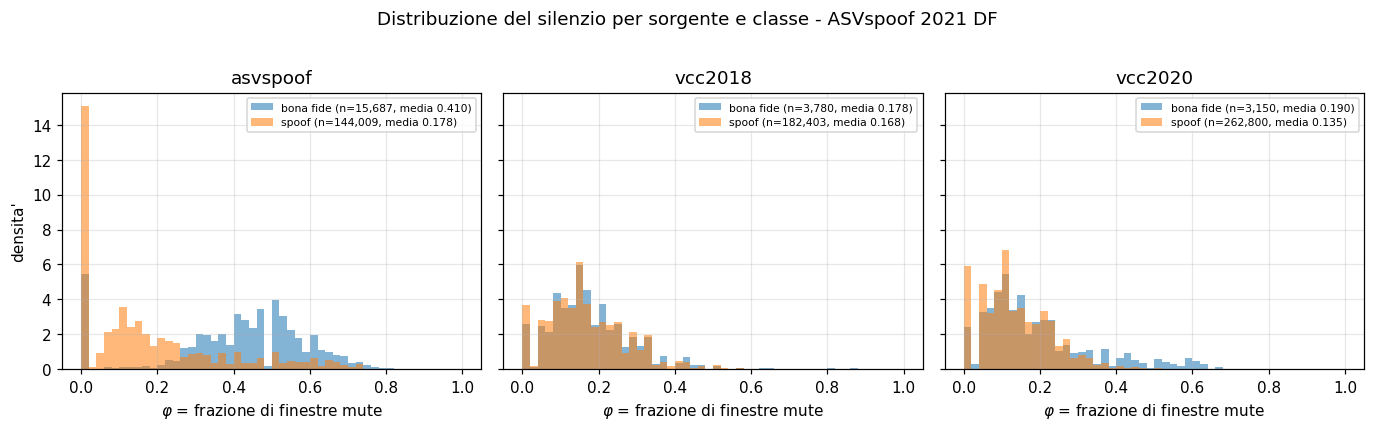

In [7]:
# --- figura 1: distribuzione di phi per classe e sorgente --------------------
fig, axes = plt.subplots(1, len(SORGENTI), figsize=(4.2 * len(SORGENTI), 3.8), sharey=True)
axes = np.atleast_1d(axes)
for ax, g in zip(axes, SORGENTI):
    for nome, cls, c in [("bona fide", 1, "C0"), ("spoof", 0, "C1")]:
        v = PHI[(SRC == g) & (Y == cls)]
        if len(v):
            ax.hist(v, bins=50, range=(0, 1), density=True, alpha=0.55, color=c,
                    label=f"{nome} (n={len(v):,}, media {v.mean():.3f})")
    ax.set_xlabel(r"$\varphi$ = frazione di finestre mute")
    ax.set_title(g); ax.grid(alpha=0.3); ax.legend(fontsize=7)
axes[0].set_ylabel("densita'")
fig.suptitle("Distribuzione del silenzio per sorgente e classe - ASVspoof 2021 DF", y=1.02)
plt.tight_layout(); plt.savefig(ANA_DIR / "fig1_phi_per_sorgente.png", bbox_inches="tight")
plt.show()

In [8]:
righe = []
for n in NOMI:
    s = SCORES[n]
    for g in ["tutte"] + SORGENTI:
        m = np.ones(N, bool) if g == "tutte" else (SRC == g)
        if m.sum() < 100:
            continue
        r = {"modello": n, "sorgente": g, "n": int(m.sum())}
        r["rho_tutti"] = round(float(spearmanr(s[m], PHI[m]).statistic), 3)
        for nome, cls in [("bf", 1), ("sp", 0)]:
            mm = m & (Y == cls)
            r[f"rho_{nome}"] = (round(float(spearmanr(s[mm], PHI[mm]).statistic), 3)
                                if mm.sum() >= 100 else np.nan)
        r["rho_lead_tutti"] = round(float(spearmanr(s[m], PHI_L[m]).statistic), 3)
        righe.append(r)

t_corr = pd.DataFrame(righe).set_index(["modello", "sorgente"])
t_corr.to_csv(ANA_DIR / "correlazione_punteggio_phi.csv")
print("=== correlazione di Spearman fra punteggio e silenzio ===")
print("   rho_tutti: su tutte le prove (in parte indotta dalla differenza fra classi)")
print("   rho_bf / rho_sp: entro la classe, non indotta")
display(t_corr)

=== correlazione di Spearman fra punteggio e silenzio ===
   rho_tutti: su tutte le prove (in parte indotta dalla differenza fra classi)
   rho_bf / rho_sp: entro la classe, non indotta


n  rho_tutti  rho_bf  rho_sp  rho_lead_tutti
modello sorgente                                                   
P       tutte     611829      0.511   0.622   0.477           0.603
        asvspoof  159696      0.664   0.174   0.590           0.732
        vcc2018   186183      0.463   0.517   0.462           0.473
        vcc2020   265950      0.370   0.625   0.366           0.532
Wf      tutte     611829      0.096   0.627   0.038           0.212
        asvspoof  159696      0.337   0.353   0.191           0.526
        vcc2018   186183      0.071   0.059   0.070           0.147
        vcc2020   265950      0.008   0.418   0.001           0.172
E       tutte     611829      0.016   0.428  -0.038          -0.000
        asvspoof  159696      0.158   0.323   0.020           0.164
        vcc2018   186183     -0.011   0.124  -0.015           0.027
        vcc2020   265950      0.026  -0.060   0.022           0.032
PWfE    tutte     611829      0.238   0.687   0.189           0.509
        asvspoof  159696      0.296   0.399   0.135           0.568
        vcc2018   186183      0.129   0.319   0.126           0.345
        vcc2020   265950      0.309   0.681   0.304           0.609

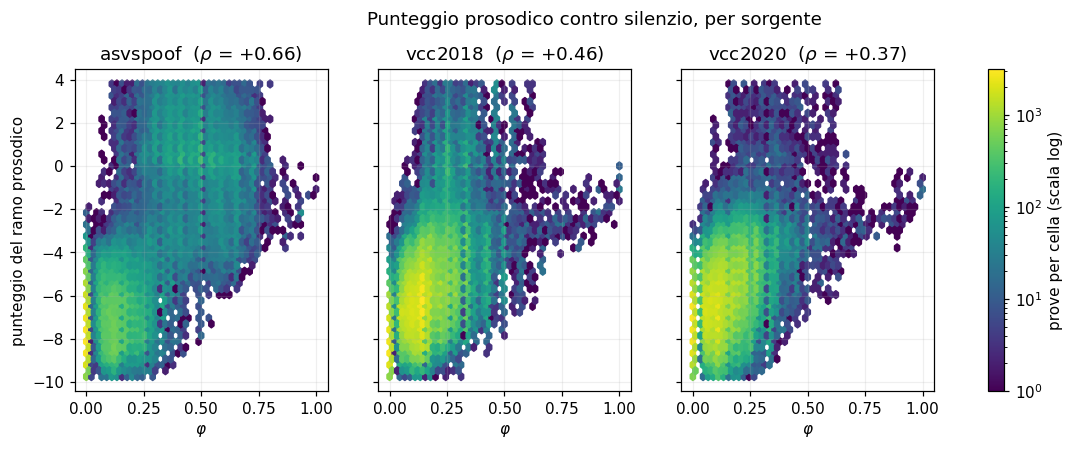

In [9]:
# --- figura 2: punteggio del ramo prosodico contro phi, per sorgente --------
if "P" in SCORES:
    fig, axes = plt.subplots(1, len(SORGENTI), figsize=(4.2 * len(SORGENTI), 3.8), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, g in zip(axes, SORGENTI):
        m = SRC == g
        hb = ax.hexbin(PHI[m], SCORES["P"][m], gridsize=45, bins="log", cmap="viridis",
                       extent=(0, 1, np.percentile(SCORES["P"], 0.5), np.percentile(SCORES["P"], 99.5)))
        rho = spearmanr(SCORES["P"][m], PHI[m]).statistic
        ax.set_xlabel(r"$\varphi$"); ax.set_title(f"{g}  ($\\rho$ = {rho:+.2f})")
        ax.grid(alpha=0.2)
    axes[0].set_ylabel("punteggio del ramo prosodico")
    fig.colorbar(hb, ax=axes.tolist(), label="prove per cella (scala log)")
    fig.suptitle("Punteggio prosodico contro silenzio, per sorgente", y=1.02)
    plt.savefig(ANA_DIR / "fig2_punteggio_vs_phi.png", bbox_inches="tight")
    plt.show()

In [10]:
BASE_C1 = (COD == "nocodec") & np.isin(SUB, ["progress", "eval"])
print(f"prove nella restrizione della Tab. VII (nocodec, progress+eval): {int(BASE_C1.sum()):,}")
if BASE_C1.sum() == 0:
    print("ATTENZIONE: nessuna prova soddisfa la restrizione; verifica i valori della colonna codec:",
          sorted(pd.unique(COD))[:12])


def gruppo(nome):
    bona, spoof = (Y == 1), (Y == 0)
    tab = {
        "All bona":        bona,
        "All spoof":       spoof,
        "ASV19 bona":      bona & (SRC == "asvspoof"),
        "ASV19 spoof":     spoof & (SRC == "asvspoof"),
        "VCC18 bona":      bona & (SRC == "vcc2018"),
        "VCC20 bona":      bona & (SRC == "vcc2020"),
        "VCC18+20 spoof":  spoof & np.isin(SRC, ["vcc2018", "vcc2020"]),
    }
    assert nome in tab, f"gruppo sconosciuto: {nome}"
    return tab[nome]


# le nove righe della Tabella VII, con i valori pubblicati per confronto
COMBINAZIONI = [
    ("All bona",   "All spoof",       37.59),
    ("VCC18 bona", "All spoof",       44.17),
    ("VCC20 bona", "All spoof",       51.14),
    ("ASV19 bona", "ASV19 spoof",     24.98),
    ("ASV19 bona", "VCC18+20 spoof",   9.19),
    ("ASV19 bona", "All spoof",       10.36),
    ("ASV19 bona", "VCC18 bona",      11.90),
    ("ASV19 bona", "VCC20 bona",      14.00),
    ("VCC18 bona", "VCC20 bona",      43.14),
]

righe = []
for pos_n, neg_n, pubblicato in COMBINAZIONI:
    p_all, n_all = gruppo(pos_n), gruppo(neg_n)
    r = {"positivo": pos_n, "negativo": neg_n, "paper_C1_%": pubblicato}
    for suff, base in [("C1", BASE_C1), ("tutte", np.ones(N, bool))]:
        p, q = p_all & base, n_all & base
        e = eer_da_insiemi(PHI[p], PHI[q])
        r[f"nostro_{suff}_%"] = round(100 * e, 2) if np.isfinite(e) else np.nan
        r[f"n_pos_{suff}"] = int(p.sum()); r[f"n_neg_{suff}"] = int(q.sum())
    righe.append(r)

t_vii = pd.DataFrame(righe)
t_vii.to_csv(ANA_DIR / "phi_come_classificatore.csv", index=False)
print("\n=== EER (%) usando phi come unico punteggio - replica della Tab. VII ===")
print("   paper_C1_%: valore pubblicato in 2210.02437, Tab. VII (VAD sull'energia)")
print("   nostro_C1_%: stessa restrizione, silenzio definito dalle caratteristiche Praat")
display(t_vii[["positivo", "negativo", "paper_C1_%", "nostro_C1_%", "nostro_tutte_%",
               "n_pos_C1", "n_neg_C1"]])

prove nella restrizione della Tab. VII (nocodec, progress+eval): 65,917

=== EER (%) usando phi come unico punteggio - replica della Tab. VII ===
   paper_C1_%: valore pubblicato in 2210.02437, Tab. VII (VAD sull'energia)
   nostro_C1_%: stessa restrizione, silenzio definito dalle caratteristiche Praat


,positivo,negativo,paper_C1_%,nostro_C1_%,nostro_tutte_%,n_pos_C1,n_neg_C1
0,All bona,All spoof,37.59,24.60,29.63,2293,63624
1,VCC18 bona,All spoof,44.17,47.15,43.76,420,63624
2,VCC20 bona,All spoof,51.14,47.77,48.47,350,63624
3,ASV19 bona,ASV19 spoof,24.98,19.89,21.02,1523,14157
4,ASV19 bona,VCC18+20 spoof,9.19,7.81,14.89,1523,49467
5,ASV19 bona,All spoof,10.36,10.31,15.75,1523,63624
6,ASV19 bona,VCC18 bona,11.90,10.27,16.78,1523,420
7,ASV19 bona,VCC20 bona,14.00,16.01,18.86,1523,350
8,VCC18 bona,VCC20 bona,43.14,47.67,48.73,420,350


In [11]:
# --- confronto diretto: phi da sola contro i modelli, per sorgente ----------
righe = []
for g in ["tutte"] + SORGENTI:
    m = np.ones(N, bool) if g == "tutte" else (SRC == g)
    r = {"sorgente": g, "n": int(m.sum()), "bona_fide": int(Y[m].sum())}
    e = compute_eer(Y[m], PHI[m])
    r["phi_da_sola"] = round(100 * e, 2) if np.isfinite(e) else np.nan
    e = compute_eer(Y[m], PHI_L[m])
    r["phi_lead_da_sola"] = round(100 * e, 2) if np.isfinite(e) else np.nan
    for n in NOMI:
        e = compute_eer(Y[m], SCORES[n][m])
        r[n] = round(100 * e, 2) if np.isfinite(e) else np.nan
    righe.append(r)
for s in SOTTOINSIEMI:
    m = SUB == s
    r = {"sorgente": f"sottoinsieme: {s}", "n": int(m.sum()), "bona_fide": int(Y[m].sum())}
    r["phi_da_sola"] = round(100 * compute_eer(Y[m], PHI[m]), 2)
    r["phi_lead_da_sola"] = round(100 * compute_eer(Y[m], PHI_L[m]), 2)
    for n in NOMI:
        r[n] = round(100 * compute_eer(Y[m], SCORES[n][m]), 2)
    righe.append(r)

t_conf = pd.DataFrame(righe).set_index("sorgente")
t_conf.to_csv(ANA_DIR / "phi_contro_modelli.csv")
print("=== EER (%): il solo silenzio contro i modelli addestrati ===")
print("   50% = caso. Se 'phi_da_sola' e' vicino all'EER di P, il ramo prosodico non sta")
print("   aggiungendo molto oltre alla misura del silenzio.")
display(t_conf)

=== EER (%): il solo silenzio contro i modelli addestrati ===
   50% = caso. Se 'phi_da_sola' e' vicino all'EER di P, il ramo prosodico non sta
   aggiungendo molto oltre alla misura del silenzio.


,n,bona_fide,phi_da_sola,phi_lead_da_sola,P,Wf,E,PWfE
sorgente,,,,,,,,
tutte,611829,22617,29.63,28.57,26.17,13.31,21.41,16.02
asvspoof,159696,15687,21.02,19.47,16.78,10.27,20.97,10.15
vcc2018,186183,3780,48.73,51.58,42.78,14.21,21.19,23.71
vcc2020,265950,3150,44.79,41.84,45.30,17.46,27.65,28.19
sottoinsieme: eval,533928,14869,30.03,29.94,26.83,12.35,22.09,16.09
sottoinsieme: progress,59325,5768,20.00,19.97,14.06,4.28,19.02,3.56
sottoinsieme: hidden,18576,1980,86.77,98.79,54.95,31.36,28.95,33.84


## Sezione 4 - Dove guarda il ramo prosodico

Si rieseguono le caratteristiche prosodiche attraverso il **checkpoint del ramo P gia' valutato**,
salvando questa volta i pesi di attenzione $a_{i,t}$ oltre al punteggio.

Il meccanismo e' l'attenzione additiva a testa singola definita nei notebook 06.1 e 10:

$$e_{i,t} = v^{\top}\tanh(W h_{i,t} + b), \qquad
a_{i,t} = \frac{\exp(e_{i,t})}{\sum_{t'=1}^{T_i}\exp(e_{i,t'})}, \qquad
z_i = \sum_{t=1}^{T_i} a_{i,t}\,h_{i,t}$$

con la softmax mascherata sui soli passi reali, quindi $\sum_t a_{i,t} = 1$ per ogni file.

**Controllo di integrita'.** I punteggi ricalcolati in questa passata vengono confrontati con
`scores_df_P.npy`. Se coincidono, i pesi di attenzione provengono con certezza dallo stesso
passaggio in avanti che ha generato gli EER riportati; se non coincidono, il percorso di codice
e' diverso e l'analisi va fermata.

**Quantita' calcolate per ogni file:**

- $\alpha_i = \sum_{t \in \text{mute}} a_{i,t}$, la massa di attenzione che cade sulle finestre mute;
- il rapporto $\alpha_i / \varphi_i$: vale 1 se il modello tratta le finestre mute come qualunque
  altra, e' minore di 1 se le evita, maggiore di 1 se le privilegia;
- l'entropia normalizzata $-\sum_t a_{i,t}\log a_{i,t} / \log T_i$: vale 1 con pesi uniformi e 0 se
  tutta la massa cade su un solo passo.

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, PackedSequence

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE, "| torch", torch.__version__)


def masked_bn(x, mask, bn):
    y = torch.zeros_like(x); y[mask] = bn(x[mask]); return y


def map_packed(p, fn):
    return PackedSequence(fn(p.data), p.batch_sizes, p.sorted_indices, p.unsorted_indices)


class SeqBranch(nn.Module):
    # identica ai notebook 06.1, 10 e 11
    def __init__(self, n_in, p=DROPOUT):
        super().__init__()
        self.conv1, self.bn_c1 = nn.Conv1d(n_in, 256, kernel_size=3, padding=1), nn.BatchNorm1d(256)
        self.conv2, self.bn_c2 = nn.Conv1d(256, 128, kernel_size=3, padding=1), nn.BatchNorm1d(128)
        self.drop = nn.Dropout(p)
        self.lstm1, self.bn_l1 = nn.LSTM(128, 100, batch_first=True), nn.BatchNorm1d(100)
        self.lstm2, self.bn_l2 = nn.LSTM(100, 50, batch_first=True), nn.BatchNorm1d(50)
        self.att_w, self.att_v = nn.Linear(50, 50), nn.Linear(50, 1, bias=False)
        self.out_dim = EMB_DIM

    def conv_block(self, h, conv, bn, mask):
        h = conv(h.transpose(1, 2)).transpose(1, 2)
        h = F.relu(masked_bn(h, mask, bn))
        return self.drop(h) * mask.unsqueeze(-1)

    def forward(self, x, lengths):
        T = x.shape[1]
        mask = torch.arange(T, device=x.device)[None, :] < lengths.to(x.device)[:, None]
        h = self.conv_block(x, self.conv1, self.bn_c1, mask)
        h = self.conv_block(h, self.conv2, self.bn_c2, mask)
        p = pack_padded_sequence(h, lengths.cpu(), batch_first=True, enforce_sorted=False)
        p, _ = self.lstm1(p)
        p = map_packed(map_packed(p, self.bn_l1), self.drop)
        p, _ = self.lstm2(p)
        p = map_packed(p, self.bn_l2)
        H, _ = pad_packed_sequence(p, batch_first=True, total_length=T)
        e = self.att_v(torch.tanh(self.att_w(H))).squeeze(-1)
        a = torch.softmax(e.masked_fill(~mask, float("-inf")), dim=1)
        return (a.unsqueeze(-1) * H).sum(1), a


class ProsodyClassifier(nn.Module):
    # notebook 06.1: chiavi branch.* e head.*
    def __init__(self, n_in, p=DROPOUT):
        super().__init__()
        self.branch = SeqBranch(n_in, p)
        self.head = nn.Sequential(nn.Linear(EMB_DIM, 50), nn.ReLU(), nn.Dropout(p), nn.Linear(50, 1))


PP = json.loads(Path(PREPROC_PROSODIA).read_text())
assert len(PP["clip_lo"]) == 2 * len(FEATURES), \
    f"preproc_prosody.json ha {len(PP['clip_lo'])} canali, attesi {2 * len(FEATURES)} (variante D)"
clip_lo = np.array(PP["clip_lo"], np.float32); clip_hi = np.array(PP["clip_hi"], np.float32)
mm_lo = np.array(PP["minmax_lo"], np.float32); mm_rng = np.array(PP["minmax_range"], np.float32)


def voiced_mask(x):
    return np.abs(x).sum(1) > 0


def dynamic_features(x):
    v = voiced_mask(x); n = len(x)
    d_ok = np.zeros(n, dtype=bool); d_ok[1:] = v[1:] & v[:-1]
    d = np.zeros_like(x); d[d_ok] = x[d_ok] - x[np.where(d_ok)[0] - 1]
    return d, d_ok


# stessa verifica delle definizioni dei notebook 06.1, 10 e 11
_x = np.array([[180.], [195.], [170.], [0.], [175.], [190.], [185.]], dtype=np.float32)
assert dynamic_features(_x)[0][:, 0].tolist() == [0, 15, -25, 0, 0, 15, -5]


def preprocessa(x):
    d, d_ok = dynamic_features(x)
    xd = np.concatenate([x, d], axis=1)
    m = np.concatenate([np.repeat(voiced_mask(x)[:, None], x.shape[1], 1),
                        np.repeat(d_ok[:, None], x.shape[1], 1)], axis=1)
    xc = np.where(m, np.clip(xd, clip_lo, clip_hi), xd)
    return ((xc - mm_lo) / mm_rng).astype(np.float32)


modello = ProsodyClassifier(2 * len(FEATURES)).to(DEVICE)
modello.load_state_dict(torch.load(CKPT_P, map_location=DEVICE), strict=True)
modello.eval()
print(f"checkpoint P caricato: {sum(p.numel() for p in modello.parameters()):,} parametri")

device: cuda | torch 2.10.0+cu128
checkpoint P caricato: 239,645 parametri


In [13]:
# --- passata sul DF salvando i pesi di attenzione ----------------------------
ATT_FLAT = np.zeros(int(T_W.sum()), dtype=np.float32)
ATT_OFF = np.concatenate([[0], np.cumsum(T_W)]).astype(np.int64)
S_RIC = np.full(N, np.nan, dtype=np.float64)          # punteggi ricalcolati, per il controllo


@torch.no_grad()
def passata(seqs, idx_glob):
    """seqs: lista di array (T, 16) gia' preprocessati. Scrive attenzione e punteggi."""
    ordine = np.argsort([-len(s) for s in seqs])
    for b in range(0, len(ordine), EVAL_BATCH):
        sel = ordine[b:b + EVAL_BATCH]
        L = np.array([len(seqs[i]) for i in sel], dtype=np.int64)
        B = torch.zeros(len(sel), int(L.max()), 2 * len(FEATURES))
        for r, i in enumerate(sel):
            B[r, :L[r]] = torch.from_numpy(seqs[i])
        z, a = modello.branch(B.to(DEVICE), torch.from_numpy(L))
        logit = modello.head(z).squeeze(-1).cpu().numpy()
        a = a.cpu().numpy()
        for r, i in enumerate(sel):
            g = idx_glob[i]
            S_RIC[g] = logit[r]
            ATT_FLAT[ATT_OFF[g]:ATT_OFF[g] + L[r]] = a[r, :L[r]]


t0 = time.perf_counter()
for k, p in enumerate(shards):
    z = np.load(p, allow_pickle=True)
    X, off, utt = z["X"], z["offsets"].astype(np.int64), z["utt_id"]
    seqs = [preprocessa(X[off[j]:off[j + 1]]) for j in range(len(utt))]
    passata(seqs, [POS[u] for u in utt])
    if (k + 1) % 50 == 0 or k + 1 == len(shards):
        print(f"  blocco {k + 1}/{len(shards)} | {time.perf_counter() - t0:.0f} s", flush=True)

assert np.isfinite(S_RIC).all(), "qualche file non e' stato elaborato"

# --- controlli di integrita' -------------------------------------------------
assert T_W.min() >= 1, "qualche file ha zero finestre: reduceat non e' applicabile"
somme = np.add.reduceat(ATT_FLAT, ATT_OFF[:-1])     # una somma per file, vettorizzata
assert np.allclose(somme, 1.0, atol=1e-3), \
    f"i pesi non sommano a 1 (min {somme.min():.5f}, max {somme.max():.5f})"

if "P" in SCORES:
    d = np.abs(S_RIC - SCORES["P"])
    print(f"\nscarto fra punteggi ricalcolati e scores_df_P.npy: "
          f"massimo {d.max():.2e}, mediano {np.median(d):.2e}")
    assert d.max() < 1e-3, ("i punteggi ricalcolati non coincidono con quelli salvati: "
                            "il percorso di codice non e' lo stesso del notebook 11")
    print("controllo superato: l'attenzione proviene dallo stesso passaggio in avanti dei punteggi")

np.savez_compressed(ANA_DIR / "attenzione_df.npz",
                    utt_id=UTT, att=ATT_FLAT, offsets=ATT_OFF)
print(f"attenzione salvata in {ANA_DIR / 'attenzione_df.npz'} "
      f"({ATT_FLAT.nbytes / 1e6:.0f} MB non compressi)")

  blocco 50/612 | 6 s
  blocco 100/612 | 10 s
  blocco 150/612 | 14 s
  blocco 200/612 | 18 s
  blocco 250/612 | 23 s
  blocco 300/612 | 27 s
  blocco 350/612 | 31 s
  blocco 400/612 | 36 s
  blocco 450/612 | 40 s
  blocco 500/612 | 44 s
  blocco 550/612 | 48 s
  blocco 600/612 | 53 s
  blocco 612/612 | 54 s

scarto fra punteggi ricalcolati e scores_df_P.npy: massimo 3.81e-06, mediano 0.00e+00
controllo superato: l'attenzione proviene dallo stesso passaggio in avanti dei punteggi
attenzione salvata in /kaggle/working/explain/attenzione_df.npz (37 MB non compressi)


In [14]:
# --- metriche di attenzione per file ----------------------------------------
ALPHA = np.zeros(N)          # massa sulle finestre mute
ENTR  = np.full(N, np.nan)   # entropia normalizzata
ARGMAX = np.full(N, -1, dtype=np.int64)   # indice della finestra di massima attenzione

t0 = time.perf_counter()
for k, p in enumerate(shards):
    z = np.load(p, allow_pickle=True)
    X, off, utt = z["X"], z["offsets"].astype(np.int64), z["utt_id"]
    mute_tutto = (np.abs(X).sum(1) == 0)
    for j, u in enumerate(utt):
        i = POS[u]
        a = ATT_FLAT[ATT_OFF[i]:ATT_OFF[i + 1]].astype(np.float64)
        m = mute_tutto[off[j]:off[j + 1]]
        T = len(a)
        ALPHA[i] = a[m].sum()
        ARGMAX[i] = int(np.argmax(a))
        if T > 1:
            q = np.clip(a, 1e-12, None)
            ENTR[i] = float(-(q * np.log(q)).sum() / np.log(T))

RAPP = np.where(PHI > 0, ALPHA / np.where(PHI > 0, PHI, 1.0), np.nan)
np.savez(ANA_DIR / "attenzione_metriche.npz", utt_id=UTT, alpha=ALPHA, entropia=ENTR,
         rapporto=RAPP, argmax=ARGMAX)

righe = []
for g in ["tutte"] + SORGENTI:
    m = np.ones(N, bool) if g == "tutte" else (SRC == g)
    for nome, cls in [("bona fide", 1), ("spoof", 0)]:
        sel = m & (Y == cls)
        if sel.sum() < MIN_PER_CLASSE:
            continue
        lo, hi = ic95(RAPP[sel])
        righe.append({"sorgente": g, "classe": nome, "n": int(sel.sum()),
                      "alpha": round(float(ALPHA[sel].mean()), 4),
                      "phi": round(float(PHI[sel].mean()), 4),
                      "rapporto": round(float(np.nanmean(RAPP[sel])), 4),
                      "ic95_rapporto": f"[{lo:.3f}, {hi:.3f}]",
                      "entropia": round(float(np.nanmean(ENTR[sel])), 4)})

t_att = pd.DataFrame(righe).set_index(["sorgente", "classe"])
t_att.to_csv(ANA_DIR / "attenzione_per_gruppo.csv")
print(f"calcolate in {time.perf_counter() - t0:.0f} s")
print("\n=== attenzione sulle finestre mute ===")
print("   rapporto alpha/phi:  = 1 il modello tratta le finestre mute come le altre")
print("                        < 1 le evita   |   > 1 le privilegia")
print("   entropia:            1 = pesi uniformi   |   0 = tutta la massa su un passo")
display(t_att)
print("Riferimento sul dev di ASVspoof 2019: rapporto 0.70-0.83, entropia 0.86-0.93")

calcolate in 26 s

=== attenzione sulle finestre mute ===
   rapporto alpha/phi:  = 1 il modello tratta le finestre mute come le altre
                        < 1 le evita   |   > 1 le privilegia
   entropia:            1 = pesi uniformi   |   0 = tutta la massa su un passo


n   alpha     phi  rapporto   ic95_rapporto  entropia
sorgente classe                                                               
tutte    bona fide   22617  0.2531  0.3410    0.7493  [0.745, 0.753]    0.9437
         spoof      589212  0.1158  0.1560    0.7265  [0.726, 0.727]    0.9493
asvspoof bona fide   15687  0.2974  0.4104    0.7065  [0.704, 0.709]    0.9503
         spoof      144009  0.1209  0.1783    0.6271  [0.626, 0.629]    0.9535
vcc2018  bona fide    3780  0.1555  0.1784    0.8721  [0.858, 0.885]    0.9317
         spoof      182403  0.1333  0.1679    0.7830  [0.782, 0.784]    0.9559
vcc2020  bona fide    3150  0.1496  0.1903    0.8025  [0.786, 0.818]    0.9256
         spoof      262800  0.1009  0.1355    0.7284  [0.727, 0.730]    0.9424

Riferimento sul dev di ASVspoof 2019: rapporto 0.70-0.83, entropia 0.86-0.93


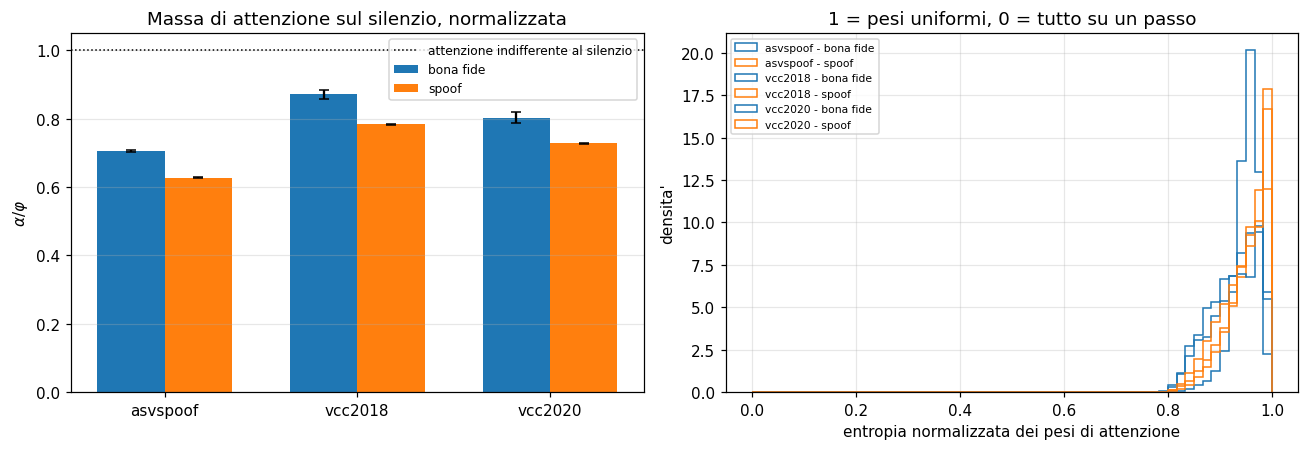

In [15]:
# --- figura 3: rapporto alpha/phi ed entropia -------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
larg = 0.35
x = np.arange(len(SORGENTI))
for k, (nome, cls, c) in enumerate([("bona fide", 1, "C0"), ("spoof", 0, "C1")]):
    med = [np.nanmean(RAPP[(SRC == g) & (Y == cls)]) for g in SORGENTI]
    err = [np.abs(np.array(ic95(RAPP[(SRC == g) & (Y == cls)])) -
                  np.nanmean(RAPP[(SRC == g) & (Y == cls)])) for g in SORGENTI]
    axes[0].bar(x + (k - 0.5) * larg, med, larg, color=c, label=nome,
                yerr=np.array(err).T, capsize=3)
axes[0].axhline(1.0, color="k", ls=":", lw=1, label="attenzione indifferente al silenzio")
axes[0].set_xticks(x); axes[0].set_xticklabels(SORGENTI)
axes[0].set_ylabel(r"$\alpha / \varphi$")
axes[0].set_title("Massa di attenzione sul silenzio, normalizzata")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3, axis="y")

for g, ls in zip(SORGENTI, ["-", "--", ":"]):
    for nome, cls, c in [("bona fide", 1, "C0"), ("spoof", 0, "C1")]:
        v = ENTR[(SRC == g) & (Y == cls)]
        v = v[np.isfinite(v)]
        if len(v):
            axes[1].hist(v, bins=60, range=(0, 1), density=True, histtype="step",
                         color=c, ls=ls, label=f"{g} - {nome}")
axes[1].set_xlabel("entropia normalizzata dei pesi di attenzione")
axes[1].set_ylabel("densita'"); axes[1].set_title("1 = pesi uniformi, 0 = tutto su un passo")
axes[1].legend(fontsize=7); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(ANA_DIR / "fig3_attenzione.png", bbox_inches="tight")
plt.show()

In [16]:
VAL_MAX = np.full((N, len(FEATURES)), np.nan, dtype=np.float64)   # alla finestra di max attenzione
VAL_PES = np.full((N, len(FEATURES)), np.nan, dtype=np.float64)   # media pesata, senza finestre mute
MAX_MUTA = np.zeros(N, dtype=bool)

t0 = time.perf_counter()
for k, p in enumerate(shards):
    z = np.load(p, allow_pickle=True)
    X, off, utt = z["X"], z["offsets"].astype(np.int64), z["utt_id"]
    mute_tutto = (np.abs(X).sum(1) == 0)
    for j, u in enumerate(utt):
        i = POS[u]
        x = X[off[j]:off[j + 1]].astype(np.float64)
        m = mute_tutto[off[j]:off[j + 1]]
        a = ATT_FLAT[ATT_OFF[i]:ATT_OFF[i + 1]].astype(np.float64)
        km = ARGMAX[i]
        MAX_MUTA[i] = bool(m[km])
        if not m[km]:
            VAL_MAX[i] = x[km]
        vivo = ~m
        if vivo.any() and a[vivo].sum() > 0:
            w = a[vivo] / a[vivo].sum()
            VAL_PES[i] = (w[:, None] * x[vivo]).sum(0)
    if (k + 1) % 50 == 0 or k + 1 == len(shards):
        print(f"  blocco {k + 1}/{len(shards)} | {time.perf_counter() - t0:.0f} s", flush=True)

print(f"calcolate in {time.perf_counter() - t0:.0f} s")
print(f"file la cui finestra di massima attenzione e' muta: {int(MAX_MUTA.sum()):,} "
      f"({100 * MAX_MUTA.mean():.1f}%)")
for g in SORGENTI:
    for nome, cls in [("bona fide", 1), ("spoof", 0)]:
        sel = (SRC == g) & (Y == cls)
        if sel.sum():
            print(f"   {g:10s} {nome:10s} {100 * MAX_MUTA[sel].mean():5.1f}%")

  blocco 50/612 | 1 s
  blocco 100/612 | 3 s
  blocco 150/612 | 4 s
  blocco 200/612 | 6 s
  blocco 250/612 | 7 s
  blocco 300/612 | 9 s
  blocco 350/612 | 10 s
  blocco 400/612 | 12 s
  blocco 450/612 | 13 s
  blocco 500/612 | 14 s
  blocco 550/612 | 16 s
  blocco 600/612 | 17 s
  blocco 612/612 | 18 s
calcolate in 18 s
file la cui finestra di massima attenzione e' muta: 30,765 (5.0%)
   asvspoof   bona fide   21.5%
   asvspoof   spoof        8.2%
   vcc2018    bona fide    8.4%
   vcc2018    spoof        3.9%
   vcc2020    bona fide    4.7%
   vcc2020    spoof        3.1%


In [17]:
# --- tabella: mediana per caratteristica, classe e sorgente -----------------
righe = []
for g in ["tutte"] + SORGENTI:
    m = np.ones(N, bool) if g == "tutte" else (SRC == g)
    for nome, cls in [("bona fide", 1), ("spoof", 0)]:
        sel = m & (Y == cls)
        if sel.sum() < MIN_PER_CLASSE:
            continue
        r = {"sorgente": g, "classe": nome, "n": int(sel.sum())}
        for f_i, (f, u) in enumerate(zip(FEATURES, UNITA)):
            v = VAL_PES[sel, f_i]
            v = v[np.isfinite(v)]
            r[f"{f} [{u}]"] = round(float(np.median(v)), 3) if len(v) else np.nan
        righe.append(r)

t_feat = pd.DataFrame(righe).set_index(["sorgente", "classe"])
t_feat.to_csv(ANA_DIR / "feature_pesate_attenzione.csv")
print("=== mediana della media pesata dall'attenzione, per caratteristica ===")
display(t_feat)

=== mediana della media pesata dall'attenzione, per caratteristica ===


n  f0_mean [Hz]  f0_std [Hz]  jitter_local [-]  \
sorgente classe                                                           
tutte    bona fide   22617       138.701       11.359             0.028   
         spoof      589212       157.733       10.326             0.025   
asvspoof bona fide   15687       126.853       10.515             0.028   
         spoof      144009       124.621        8.547             0.024   
vcc2018  bona fide    3780       161.172       13.068             0.027   
         spoof      182403       161.667       10.415             0.022   
vcc2020  bona fide    3150       168.400       12.316             0.029   
         spoof      262800       175.134       11.096             0.027   

                    shimmer_local [-]  hnr_mean [dB]  hnr_std [dB]  \
sorgente classe                                                      
tutte    bona fide              0.103         11.223         4.947   
         spoof                  0.115         11.578         4.612   
asvspoof bona fide              0.104         11.001         4.929   
         spoof                  0.113         11.011         4.669   
vcc2018  bona fide              0.099         11.725         4.773   
         spoof                  0.111         12.520         4.362   
vcc2020  bona fide              0.100         11.694         5.245   
         spoof                  0.119         11.284         4.751   

                    intensity_mean [dB]  intensity_std [dB]  
sorgente classe                                              
tutte    bona fide               70.820               7.458  
         spoof                   70.642               8.038  
asvspoof bona fide               70.784               7.159  
         spoof                   72.270               7.238  
vcc2018  bona fide               70.461               8.519  
         spoof                   69.128               8.330  
vcc2020  bona fide               71.386               8.058  
         spoof                   70.772               8.244

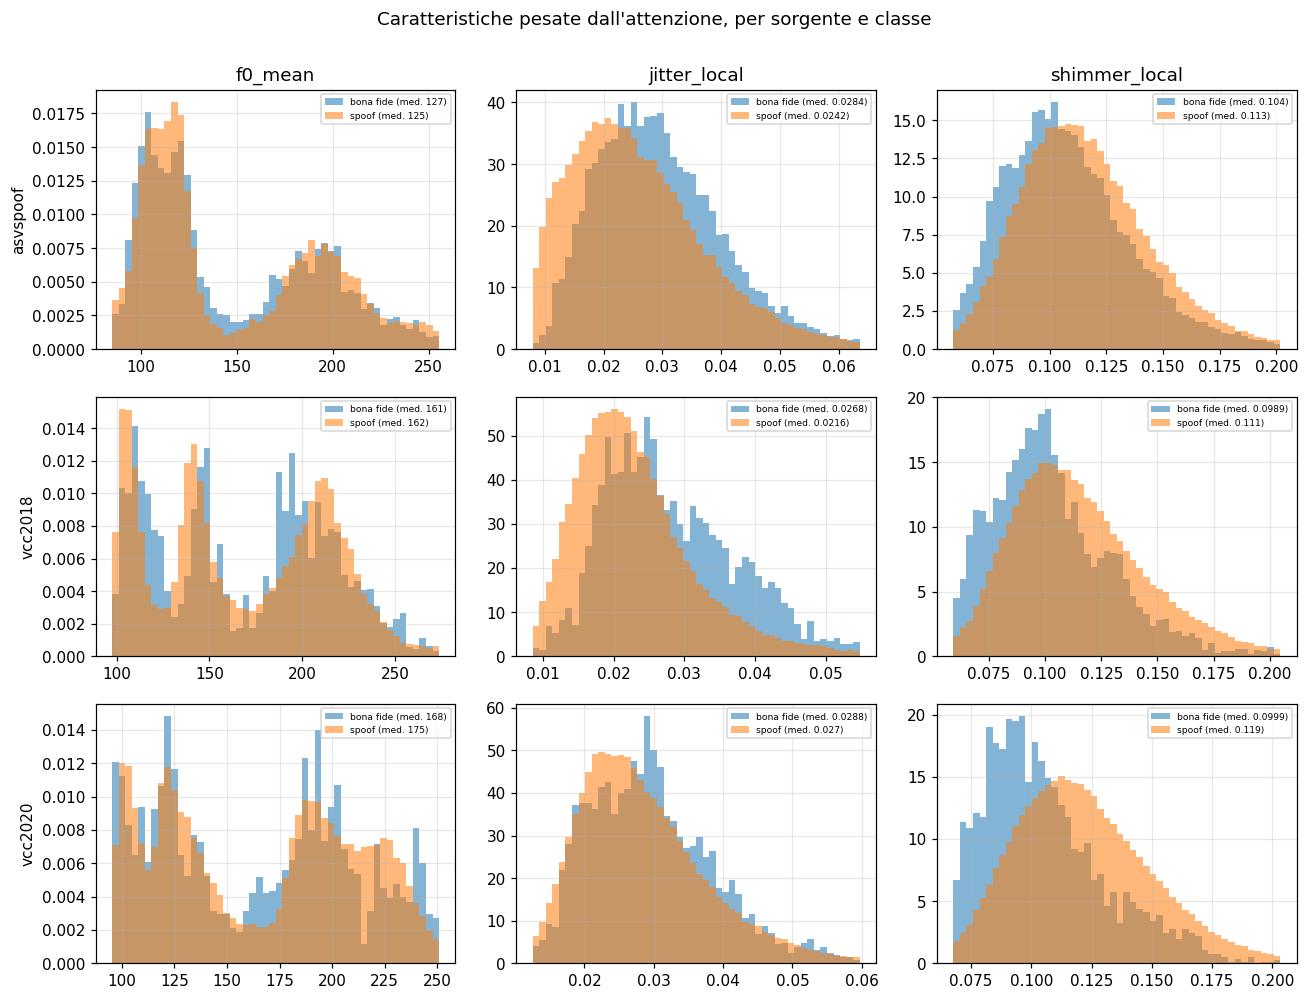

In [18]:
# --- figura 4: le tre caratteristiche della Fig. 6 di Pitch Imperfect -------
TRE = ["f0_mean", "jitter_local", "shimmer_local"]
idx_tre = [FEATURES.index(f) for f in TRE]
fig, axes = plt.subplots(len(SORGENTI), len(TRE),
                         figsize=(4.0 * len(TRE), 3.0 * len(SORGENTI)), squeeze=False)
for r, g in enumerate(SORGENTI):
    for c, (f, fi) in enumerate(zip(TRE, idx_tre)):
        ax = axes[r][c]
        dati = []
        for nome, cls, col in [("bona fide", 1, "C0"), ("spoof", 0, "C1")]:
            v = VAL_PES[(SRC == g) & (Y == cls), fi]
            v = v[np.isfinite(v)]
            dati.append((nome, v, col))
        lim = np.percentile(np.concatenate([d[1] for d in dati if len(d[1])]), [1, 99]) \
            if any(len(d[1]) for d in dati) else (0, 1)
        for nome, v, col in dati:
            if len(v):
                ax.hist(v, bins=50, range=tuple(lim), density=True, alpha=0.55, color=col,
                        label=f"{nome} (med. {np.median(v):.3g})")
        if r == 0:
            ax.set_title(f)
        if c == 0:
            ax.set_ylabel(g)
        ax.legend(fontsize=6); ax.grid(alpha=0.3)
fig.suptitle("Caratteristiche pesate dall'attenzione, per sorgente e classe", y=1.005)
plt.tight_layout(); plt.savefig(ANA_DIR / "fig4_feature_attenzione.png", bbox_inches="tight")
plt.show()

In [19]:
SOGLIE, ERRORE = {}, {}
righe = []
for n in NOMI:
    thr, frr, far = soglia_eer(Y, SCORES[n])
    SOGLIE[n] = thr
    pred = (SCORES[n] >= thr).astype(np.int8)
    ERRORE[n] = (pred != Y)
    righe.append({"modello": n, "soglia_eer": round(thr, 4),
                  "P_miss_%": round(100 * frr, 2), "P_fa_%": round(100 * far, 2),
                  "errori": int(ERRORE[n].sum()),
                  "errori_%": round(100 * ERRORE[n].mean(), 2)})
t_sog = pd.DataFrame(righe).set_index("modello")
print("=== punto di lavoro: soglia di EER di ciascun modello ===")
display(t_sog)

# concordanza fra i punteggi
print("\n=== correlazione di Spearman fra i punteggi dei modelli ===")
M = pd.DataFrame({n: SCORES[n] for n in NOMI})
display(M.corr(method="spearman").round(3))

=== punto di lavoro: soglia di EER di ciascun modello ===


,soglia_eer,P_miss_%,P_fa_%,errori,errori_%
modello,,,,,
P,-4.8062,26.17,26.17,160120,26.17
Wf,-7.6601,13.31,13.31,81448,13.31
E,-2.6276,21.41,21.41,131019,21.41
PWfE,-7.5565,16.02,16.02,98009,16.02



=== correlazione di Spearman fra i punteggi dei modelli ===


,P,Wf,E,PWfE
P,1.000,0.155,0.008,0.348
Wf,0.155,1.000,0.499,0.624
E,0.008,0.499,1.000,0.391
PWfE,0.348,0.624,0.391,1.000


In [20]:
if "Wf" in ERRORE and "PWfE" in ERRORE:
    a, b = ERRORE["Wf"], ERRORE["PWfE"]
    tab = pd.crosstab(pd.Series(np.where(a, "Wf sbaglia", "Wf indovina"), name=""),
                      pd.Series(np.where(b, "PWfE sbaglia", "PWfE indovina"), name=""))
    print("=== concordanza alla soglia di EER ===")
    display(tab)

    SOLO_PWFE = (~a) & b        # Wf indovina, PWfE sbaglia: il costo della fusione
    SOLO_WF   = a & (~b)        # PWfE indovina, Wf sbaglia: il guadagno della fusione
    print(f"\nWf indovina e PWfE sbaglia: {int(SOLO_PWFE.sum()):,} prove")
    print(f"PWfE indovina e Wf sbaglia: {int(SOLO_WF.sum()):,} prove")
    print(f"saldo netto a favore di Wf: {int(SOLO_PWFE.sum() - SOLO_WF.sum()):,} prove\n")

    righe = []
    for nome, m in [("Wf indovina, PWfE sbaglia", SOLO_PWFE),
                    ("PWfE indovina, Wf sbaglia", SOLO_WF),
                    ("riferimento: tutto il DF", np.ones(N, bool))]:
        r = {"insieme": nome, "n": int(m.sum()),
             "quota_bona_fide": round(float(Y[m].mean()), 3),
             "phi_media": round(float(PHI[m].mean()), 3)}
        for g in SORGENTI:
            r[f"quota_{g}"] = round(float((SRC[m] == g).mean()), 3)
        righe.append(r)
    t_err = pd.DataFrame(righe).set_index("insieme")
    t_err.to_csv(ANA_DIR / "analisi_errori.csv")
    print("=== composizione degli insiemi di disaccordo ===")
    print("   confronta ciascuna riga con il riferimento: una quota molto piu' alta")
    print("   indica dove la fusione costa o guadagna")
    display(t_err)

    # i dieci attacchi su cui la fusione costa di piu'
    cnt = (pd.Series(index.loc[SOLO_PWFE, "attack"].values).value_counts().head(10)
           .rename("Wf indovina, PWfE sbaglia").to_frame())
    cnt["totale prove dell'attacco"] = [int((index["attack"] == a_).sum()) for a_ in cnt.index]
    cnt["quota"] = (cnt.iloc[:, 0] / cnt["totale prove dell'attacco"]).round(3)
    print("\n=== dieci attacchi su cui la fusione costa di piu' ===")
    display(cnt)

=== concordanza alla soglia di EER ===


,PWfE indovina,PWfE sbaglia
,,
Wf indovina,478053,52328
Wf sbaglia,35767,45681



Wf indovina e PWfE sbaglia: 52,328 prove
PWfE indovina e Wf sbaglia: 35,767 prove
saldo netto a favore di Wf: 16,561 prove

=== composizione degli insiemi di disaccordo ===
   confronta ciascuna riga con il riferimento: una quota molto piu' alta
   indica dove la fusione costa o guadagna


,n,quota_bona_fide,phi_media,quota_asvspoof,quota_vcc2018,quota_vcc2020
insieme,,,,,,
"Wf indovina, PWfE sbaglia",52328,0.030,0.206,0.174,0.284,0.542
"PWfE indovina, Wf sbaglia",35767,0.026,0.134,0.360,0.101,0.539
riferimento: tutto il DF,611829,0.037,0.163,0.261,0.304,0.435



=== dieci attacchi su cui la fusione costa di piu' ===


,"Wf indovina, PWfE sbaglia",totale prove dell'attacco,quota
Task2-team28,1602,5400,0.297
A19,1586,11016,0.144
-,1560,22617,0.069
Task2-team24,1521,5400,0.282
A10,1349,11241,0.120
HUB-D02,1253,5040,0.249
Task2-team07,1234,5400,0.229
A18,1200,10863,0.110
Task2-team23,1115,5400,0.206
Task1-team28,1013,3600,0.281


# ATTRIBUZIONE SHAP

In [21]:
try:
    from captum.attr import FeatureAblation, KernelShap
except ImportError:
    import subprocess, sys as _s
    subprocess.run([_s.executable, "-m", "pip", "install", "-q", "captum"], check=True)
    from captum.attr import FeatureAblation, KernelShap
import captum
print("captum", captum.__version__)

N_CAMPIONE = int(os.environ.get("N_CAMPIONE", 600))   # file per l'attribuzione
N_KSHAP    = int(os.environ.get("N_KSHAP", 0))        # campioni di KernelShap; 0 = salta

# --- campione stratificato per sorgente e classe -----------------------------
g = np.random.default_rng(SEED)
celle, per_cella = [], max(1, N_CAMPIONE // (2 * len(SORGENTI)))
for s in SORGENTI:
    for cls in (1, 0):
        cand = np.where((SRC == s) & (Y == cls))[0]
        if len(cand):
            celle.append(g.choice(cand, size=min(per_cella, len(cand)), replace=False))
CAMP = np.sort(np.concatenate(celle))
print(f"campione: {len(CAMP)} file, {per_cella} per cella sorgente x classe")

# --- sequenze preprocessate dei soli file campionati -------------------------
voluti = set(UTT[CAMP])
SEQ = {}
for p in shards:
    z = np.load(p, allow_pickle=True)
    X, off, uu = z["X"], z["offsets"].astype(np.int64), z["utt_id"]
    for j, u in enumerate(uu):
        if u in voluti:
            SEQ[POS[u]] = preprocessa(X[off[j]:off[j + 1]])
assert len(SEQ) == len(CAMP), f"recuperate {len(SEQ)} sequenze su {len(CAMP)}"

# --- riferimento: media per canale sulle sole finestre SONORE ----------------
# Una finestra e' muta se lo era nelle caratteristiche GREZZE: dopo il preprocessing
# non vale piu' zero, quindi la maschera va presa dai blocchi originali.
somma = np.zeros(2 * len(FEATURES)); conta = 0
for p in shards:
    z = np.load(p, allow_pickle=True)
    X, off, uu = z["X"], z["offsets"].astype(np.int64), z["utt_id"]
    mute_tutto = (np.abs(X).sum(1) == 0)
    for j, u in enumerate(uu):
        if u not in voluti:
            continue
        x = SEQ[POS[u]]; m = mute_tutto[off[j]:off[j + 1]]
        if (~m).any():
            somma += x[~m].sum(0); conta += int((~m).sum())
RIFERIMENTO = (somma / conta).astype(np.float32)
print(f"riferimento calcolato su {conta:,} finestre sonore")
print("   NOTA: sostituire un canale con una costante porta l'ingresso fuori dalla varieta' dei")
print("   dati reali. E' un limite comune a tutti i metodi perturbativi e va dichiarato.")


class AvvolgiP(nn.Module):
    """Espone il logit del ramo prosodico come f(x) per Captum."""
    def __init__(self, m):
        super().__init__(); self.m = m

    def forward(self, x):
        L = torch.full((x.shape[0],), x.shape[1], dtype=torch.long)
        z, _ = self.m.branch(x, L)
        return self.m.head(z)


avvolto = AvvolgiP(modello).to(DEVICE).eval()
abl = FeatureAblation(avvolto)

# verifica della convenzione sui gruppi sul modello vero
_i = int(CAMP[0]); _x = torch.from_numpy(SEQ[_i])[None].to(DEVICE)
_mk = torch.arange(2 * len(FEATURES), device=DEVICE).repeat(_x.shape[1], 1)[None]
_b = torch.from_numpy(RIFERIMENTO).to(DEVICE).expand_as(_x)
_a = abl.attribute(_x, baselines=_b, feature_mask=_mk, target=0)
assert torch.allclose(_a[0, :, 0], _a[0, 0, 0].expand(_x.shape[1]), atol=1e-5), \
    "Captum non replica il valore del gruppo: rivedere la lettura dell'attribuzione"
print("convenzione sui gruppi verificata sul modello reale")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 6.3 MB/s eta 0:00:00
captum 0.9.0
campione: 600 file, 100 per cella sorgente x classe
riferimento calcolato su 7,734 finestre sonore
   NOTA: sostituire un canale con una costante porta l'ingresso fuori dalla varieta' dei
   dati reali. E' un limite comune a tutti i metodi perturbativi e va dichiarato.
convenzione sui gruppi verificata sul modello reale


In [22]:
# --- 7.1 attribuzione PER CANALE --------------------------------------------
CH = 2 * len(FEATURES)
NOMI_CH = FEATURES + [f"d_{f}" for f in FEATURES]
ATTR_CH = np.full((len(CAMP), CH), np.nan, dtype=np.float64)
ATTR_CH_KS = np.full((len(CAMP), CH), np.nan, dtype=np.float64) if N_KSHAP else None
ks = KernelShap(avvolto) if N_KSHAP else None

t0 = time.perf_counter()
for r, i in enumerate(CAMP):
    x = torch.from_numpy(SEQ[int(i)])[None].to(DEVICE)
    T = x.shape[1]
    mk = torch.arange(CH, device=DEVICE).repeat(T, 1)[None]        # gruppo = canale
    b = torch.from_numpy(RIFERIMENTO).to(DEVICE).expand_as(x)
    a = abl.attribute(x, baselines=b, feature_mask=mk, target=0,
                      perturbations_per_eval=min(CH, 16))
    ATTR_CH[r] = a[0, 0, :].detach().cpu().numpy()                 # valori replicati: riga 0
    if ks is not None:
        a2 = ks.attribute(x, baselines=b, feature_mask=mk, target=0,
                          n_samples=N_KSHAP, perturbations_per_eval=32)
        ATTR_CH_KS[r] = a2[0, 0, :].detach().cpu().numpy()
    if (r + 1) % 200 == 0 or r + 1 == len(CAMP):
        print(f"  {r + 1}/{len(CAMP)} file | {time.perf_counter() - t0:.0f} s", flush=True)

righe = []
for s in ["tutte"] + SORGENTI:
    for nome, cls in [("bona fide", 1), ("spoof", 0)]:
        sel = ((np.ones(len(CAMP), bool) if s == "tutte" else (SRC[CAMP] == s))
               & (Y[CAMP] == cls))
        if sel.sum() < 5:
            continue
        r = {"sorgente": s, "classe": nome, "n": int(sel.sum())}
        imp = np.abs(ATTR_CH[sel]).mean(0)                          # importanza, segno a parte
        for c, nc in enumerate(NOMI_CH):
            r[nc] = round(float(imp[c]), 4)
        righe.append(r)
t_ch = pd.DataFrame(righe).set_index(["sorgente", "classe"])
t_ch.to_csv(ANA_DIR / "shap_per_canale.csv")
np.savez(ANA_DIR / "shap_attribuzioni.npz", indici=CAMP, utt_id=UTT[CAMP],
         attr_canale=ATTR_CH, canali=np.array(NOMI_CH),
         **({"attr_canale_kernelshap": ATTR_CH_KS} if N_KSHAP else {}))

print("\n=== importanza media per canale (|attribuzione|) ===")
display(t_ch)
print("\nclassifica complessiva dei canali:")
ordine = np.argsort(-np.abs(ATTR_CH).mean(0))
for k, c in enumerate(ordine[:8], 1):
    print(f"  {k}. {NOMI_CH[c]:18s} {np.abs(ATTR_CH).mean(0)[c]:.4f}")

  200/600 file | 2 s
  400/600 file | 4 s
  600/600 file | 6 s

=== importanza media per canale (|attribuzione|) ===


n  f0_mean  f0_std  jitter_local  shimmer_local  \
sorgente classe                                                         
tutte    bona fide  300   0.6049  0.3358        0.4026         1.1637   
         spoof      300   0.3748  0.3378        0.4624         0.6692   
asvspoof bona fide  100   0.6465  0.3891        0.4804         1.9247   
         spoof      100   0.3511  0.3357        0.4733         0.7521   
vcc2018  bona fide  100   0.5291  0.2897        0.3676         0.6644   
         spoof      100   0.3651  0.4188        0.6379         0.6670   
vcc2020  bona fide  100   0.6390  0.3287        0.3597         0.9018   
         spoof      100   0.4081  0.2589        0.2759         0.5885   

                    hnr_mean  hnr_std  intensity_mean  intensity_std  \
sorgente classe                                                        
tutte    bona fide    0.6121   0.6494          1.6709         0.6440   
         spoof        0.5698   0.4304          0.5771         0.5367   
asvspoof bona fide    0.5151   0.9818          3.3318         0.7415   
         spoof        0.6356   0.4522          0.7890         0.5871   
vcc2018  bona fide    0.7437   0.4381          0.7293         0.6403   
         spoof        0.6188   0.3917          0.5079         0.6256   
vcc2020  bona fide    0.5775   0.5282          0.9518         0.5501   
         spoof        0.4550   0.4473          0.4344         0.3974   

                    d_f0_mean  d_f0_std  d_jitter_local  d_shimmer_local  \
sorgente classe                                                            
tutte    bona fide     0.1511    0.0582          0.0868           0.3202   
         spoof         0.0902    0.0361          0.0846           0.2068   
asvspoof bona fide     0.2076    0.0725          0.1024           0.5429   
         spoof         0.0863    0.0439          0.1057           0.2168   
vcc2018  bona fide     0.1474    0.0526          0.0911           0.1606   
         spoof         0.1034    0.0277          0.0727           0.2040   
vcc2020  bona fide     0.0985    0.0496          0.0670           0.2570   
         spoof         0.0810    0.0367          0.0754           0.1997   

                    d_hnr_mean  d_hnr_std  d_intensity_mean  d_intensity_std  
sorgente classe                                                               
tutte    bona fide      0.4119     0.2410            0.2812           0.4517  
         spoof          0.2200     0.1698            0.2276           0.3335  
asvspoof bona fide      0.6689     0.3180            0.3787           0.4842  
         spoof          0.2557     0.1803            0.1975           0.3116  
vcc2018  bona fide      0.2546     0.1908            0.2606           0.4668  
         spoof          0.2190     0.1595            0.2871           0.3818  
vcc2020  bona fide      0.3123     0.2142            0.2044           0.4041  
         spoof          0.1855     0.1695            0.1981           0.3070


classifica complessiva dei canali:
  1. intensity_mean     1.1240
  2. shimmer_local      0.9164
  3. hnr_mean           0.5909
  4. intensity_std      0.5903
  5. hnr_std            0.5399
  6. f0_mean            0.4898
  7. jitter_local       0.4325
  8. d_intensity_std    0.3926


In [23]:
# --- 7.2 attribuzione PER FINESTRA e confronto con l'attenzione --------------
# Domanda: i passi che l'attenzione pesa di piu' sono quelli che, rimossi, cambiano
# davvero il punteggio? E' il test al centro del dibattito Jain & Wallace / Wiegreffe & Pinter.
RHO = np.full(len(CAMP), np.nan)
ATTR_MUTE = np.full(len(CAMP), np.nan)     # quota di |attribuzione| sulle finestre mute

mute_di = {}
for p in shards:
    z = np.load(p, allow_pickle=True)
    X, off, uu = z["X"], z["offsets"].astype(np.int64), z["utt_id"]
    mt = (np.abs(X).sum(1) == 0)
    for j, u in enumerate(uu):
        if u in voluti:
            mute_di[POS[u]] = mt[off[j]:off[j + 1]]

t0 = time.perf_counter()
for r, i in enumerate(CAMP):
    i = int(i)
    x = torch.from_numpy(SEQ[i])[None].to(DEVICE)
    T = x.shape[1]
    if T < 3:
        continue
    mk = torch.arange(T, device=DEVICE).repeat(CH, 1).T[None]       # gruppo = finestra
    b = torch.from_numpy(RIFERIMENTO).to(DEVICE).expand_as(x)
    a = abl.attribute(x, baselines=b, feature_mask=mk, target=0,
                      perturbations_per_eval=min(T, 32))
    att_t = a[0, :, 0].detach().cpu().numpy()                       # valori replicati: colonna 0
    pesi = ATT_FLAT[ATT_OFF[i]:ATT_OFF[i] + T].astype(np.float64)
    if np.ptp(att_t) > 0 and np.ptp(pesi) > 0:
        RHO[r] = spearmanr(np.abs(att_t), pesi).statistic
    m = mute_di[i]
    tot = np.abs(att_t).sum()
    if tot > 0:
        ATTR_MUTE[r] = np.abs(att_t)[m].sum() / tot
    if (r + 1) % 200 == 0 or r + 1 == len(CAMP):
        print(f"  {r + 1}/{len(CAMP)} file | {time.perf_counter() - t0:.0f} s", flush=True)

righe = []
for s in ["tutte"] + SORGENTI:
    for nome, cls in [("bona fide", 1), ("spoof", 0)]:
        sel = ((np.ones(len(CAMP), bool) if s == "tutte" else (SRC[CAMP] == s))
               & (Y[CAMP] == cls) & np.isfinite(RHO))
        if sel.sum() < 5:
            continue
        lo, hi = ic95(RHO[sel])
        righe.append({"sorgente": s, "classe": nome, "n": int(sel.sum()),
                      "rho_medio": round(float(np.nanmean(RHO[sel])), 3),
                      "ic95": f"[{lo:.3f}, {hi:.3f}]",
                      "quota_rho_positivi": round(float((RHO[sel] > 0).mean()), 3),
                      "attr_su_mute": round(float(np.nanmean(ATTR_MUTE[sel])), 3),
                      "phi": round(float(PHI[CAMP][sel].mean()), 3)})
t_rho = pd.DataFrame(righe).set_index(["sorgente", "classe"])
t_rho.to_csv(ANA_DIR / "attenzione_vs_ablazione.csv")
np.savez(ANA_DIR / "rho_attenzione_ablazione.npz", indici=CAMP, rho=RHO, attr_mute=ATTR_MUTE)

print("\n=== concordanza fra peso di attenzione e importanza per ablazione ===")
print("   rho ~ +1: i passi molto attenzionati sono quelli che contano davvero")
print("   rho ~  0: l'attenzione non predice l'importanza misurata per perturbazione")
print("   attr_su_mute: quota di |attribuzione| che cade sulle finestre mute; si confronta con phi")
display(t_rho)
print("\nATTENZIONE: una concordanza alta NON dimostra che l'attenzione sia una spiegazione")
print("causale. Dice che, in questo modello, concorda con l'importanza misurata per occlusione.")

  200/600 file | 3 s
  400/600 file | 5 s
  600/600 file | 7 s

=== concordanza fra peso di attenzione e importanza per ablazione ===
   rho ~ +1: i passi molto attenzionati sono quelli che contano davvero
   rho ~  0: l'attenzione non predice l'importanza misurata per perturbazione
   attr_su_mute: quota di |attribuzione| che cade sulle finestre mute; si confronta con phi


n  rho_medio             ic95  quota_rho_positivi  \
sorgente classe                                                           
tutte    bona fide  300      0.210   [0.169, 0.249]               0.713   
         spoof      300      0.281   [0.246, 0.312]               0.827   
asvspoof bona fide  100     -0.044  [-0.110, 0.024]               0.400   
         spoof      100      0.245   [0.186, 0.312]               0.820   
vcc2018  bona fide  100      0.325   [0.263, 0.382]               0.860   
         spoof      100      0.264   [0.208, 0.320]               0.780   
vcc2020  bona fide  100      0.349   [0.296, 0.401]               0.880   
         spoof      100      0.334   [0.275, 0.394]               0.880   

                    attr_su_mute    phi  
sorgente classe                          
tutte    bona fide         0.319  0.239  
         spoof             0.182  0.163  
asvspoof bona fide         0.487  0.399  
         spoof             0.167  0.204  
vcc2018  bona fide         0.225  0.161  
         spoof             0.185  0.153  
vcc2020  bona fide         0.243  0.158  
         spoof             0.195  0.134


ATTENZIONE: una concordanza alta NON dimostra che l'attenzione sia una spiegazione
causale. Dice che, in questo modello, concorda con l'importanza misurata per occlusione.


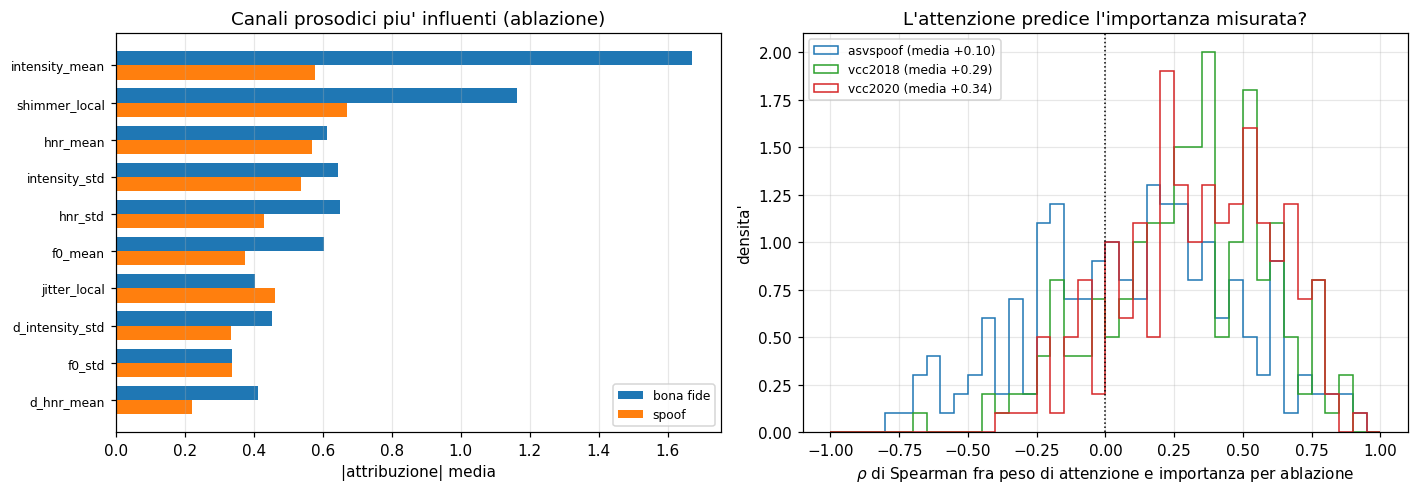

In [24]:
# --- figura 5: attribuzione per canale e concordanza con l'attenzione -------
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
ordine = np.argsort(-np.abs(ATTR_CH).mean(0))[:10]
xpos = np.arange(len(ordine))
for k, (nome, cls, c) in enumerate([("bona fide", 1, "C0"), ("spoof", 0, "C1")]):
    sel = Y[CAMP] == cls
    axes[0].barh(xpos + (k - 0.5) * 0.38, np.abs(ATTR_CH[sel]).mean(0)[ordine],
                 0.38, color=c, label=nome)
axes[0].set_yticks(xpos); axes[0].set_yticklabels([NOMI_CH[c] for c in ordine], fontsize=8)
axes[0].invert_yaxis(); axes[0].set_xlabel("|attribuzione| media")
axes[0].set_title("Canali prosodici piu' influenti (ablazione)")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3, axis="x")

for s, c in zip(SORGENTI, ["C0", "C2", "C3"]):
    v = RHO[(SRC[CAMP] == s) & np.isfinite(RHO)]
    if len(v):
        axes[1].hist(v, bins=40, range=(-1, 1), density=True, histtype="step",
                     color=c, label=f"{s} (media {v.mean():+.2f})")
axes[1].axvline(0, color="k", ls=":", lw=1)
axes[1].set_xlabel(r"$\rho$ di Spearman fra peso di attenzione e importanza per ablazione")
axes[1].set_ylabel("densita'")
axes[1].set_title("L'attenzione predice l'importanza misurata?")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(ANA_DIR / "fig5_attribuzione.png", bbox_inches="tight")
plt.show()

In [27]:
CKPT_PWFE    = os.environ.get("CKPT_PWFE", "/kaggle/input/datasets/angelopaldino/models/Modelli/model_PWfE_seed0.pt")       # .../model_PWfE_seed0.pt
STANDARDIZER = os.environ.get("STANDARDIZER", "/kaggle/input/datasets/angelopaldino/models/Modelli/standardizer.json")    # .../standardizer.json
PTM_DIR      = os.environ.get("PTM_DIR", "/kaggle/input/datasets/angelopaldino/features/resultsPTM/df2021/ptm")         # cartella dei blocchi ptm_*.npz
PTM_DIR_EXTRA = os.environ.get("PTM_DIR_EXTRA", "/kaggle/input/datasets/angelo01paldino/ptm-extra/df2021/ptm_extra")  # seconda cartella, eventuale

pronti = all(p and Path(p).exists() for p in [CKPT_PWFE, STANDARDIZER]) and \
    bool(sorted(Path(PTM_DIR).glob("ptm_*.npz")) if PTM_DIR and Path(PTM_DIR).exists() else [])

if not pronti:
    print("sezione 7.3 saltata: impostare CKPT_PWFE, STANDARDIZER e PTM_DIR")
else:
    D_WHISPER, D_ECAPA = 512, 192

    class FileBranch(nn.Module):
        def __init__(self, n_in, p=DROPOUT):
            super().__init__()
            self.net = nn.Sequential(nn.Linear(n_in, 128), nn.BatchNorm1d(128), nn.ReLU(),
                                     nn.Dropout(p), nn.Linear(128, EMB_DIM))
        def forward(self, x):
            return self.net(x)

    class DetectorFull(nn.Module):
        def __init__(self, n_in_p, p=DROPOUT):
            super().__init__()
            self.pb = SeqBranch(n_in_p, p)
            self.wfb = FileBranch(D_WHISPER, p); self.eb = FileBranch(D_ECAPA, p)
            self.bn_fuse = nn.ModuleList([nn.BatchNorm1d(EMB_DIM) for _ in range(3)])
            self.head = nn.Sequential(nn.Linear(3 * EMB_DIM, 50), nn.ReLU(),
                                      nn.Dropout(p), nn.Linear(50, 1))

    pwfe = DetectorFull(2 * len(FEATURES)).to(DEVICE)
    pwfe.load_state_dict(torch.load(CKPT_PWFE, map_location=DEVICE), strict=True)
    pwfe.eval()
    ST = json.loads(Path(STANDARDIZER).read_text())
    w_mu = np.array(ST["whisper_file_mean"], np.float32); w_sd = np.array(ST["whisper_file_std"], np.float32)
    e_mu = np.array(ST["ecapa_mean"], np.float32); e_sd = np.array(ST["ecapa_std"], np.float32)

    # caratteristiche PTM dei soli file campionati
    WM = np.full((len(CAMP), D_WHISPER), np.nan, np.float32)
    EC = np.full((len(CAMP), D_ECAPA), np.nan, np.float32)
    riga_di = {int(i): r for r, i in enumerate(CAMP)}
    ptm_shards = sorted(Path(PTM_DIR).glob("ptm_*.npz"))
    if PTM_DIR_EXTRA and Path(PTM_DIR_EXTRA).exists():
        ptm_shards += sorted(Path(PTM_DIR_EXTRA).glob("ptm_*.npz"))
    for p in ptm_shards:
        z = np.load(p, allow_pickle=True)
        for j, u in enumerate(z["utt_id"]):
            if u in voluti:
                r = riga_di[POS[u]]
                WM[r] = z["whisper_mean"][j]; EC[r] = z["ecapa"][j]
    assert np.isfinite(WM).all() and np.isfinite(EC).all(), "PTM mancanti per qualche file campionato"
    WM = (WM - w_mu) / w_sd; EC = (EC - e_mu) / e_sd

    # i tre riassunti normalizzati, calcolati una volta sola
    Z = np.zeros((len(CAMP), 3 * EMB_DIM), dtype=np.float32)
    with torch.no_grad():
        for r, i in enumerate(CAMP):
            x = torch.from_numpy(SEQ[int(i)])[None].to(DEVICE)
            zp, _ = pwfe.pb(x, torch.tensor([x.shape[1]]))
            parts = [zp, pwfe.wfb(torch.from_numpy(WM[r])[None].to(DEVICE)),
                     pwfe.eb(torch.from_numpy(EC[r])[None].to(DEVICE))]
            parts = [bn(z) for bn, z in zip(pwfe.bn_fuse, parts)]
            Z[r] = torch.cat(parts, 1).cpu().numpy()

    testa = pwfe.head
    abl_h = FeatureAblation(testa)
    mk_h = torch.cat([torch.full((EMB_DIM,), k) for k in range(3)])[None].to(DEVICE)
    base_h = torch.from_numpy(Z.mean(0))[None].to(DEVICE)
    ATTR_RAMO = np.zeros((len(CAMP), 3))
    with torch.no_grad():
        for r in range(len(CAMP)):
            zz = torch.from_numpy(Z[r])[None].to(DEVICE)
            a = abl_h.attribute(zz, baselines=base_h, feature_mask=mk_h, target=0)
            ATTR_RAMO[r] = [float(a[0, k * EMB_DIM]) for k in range(3)]   # valore replicato

    RAMI = ["P (prosodia)", "Wf (Whisper)", "E (ECAPA)"]
    righe = []
    for s in ["tutte"] + SORGENTI:
        for nome, cls in [("bona fide", 1), ("spoof", 0)]:
            sel = ((np.ones(len(CAMP), bool) if s == "tutte" else (SRC[CAMP] == s))
                   & (Y[CAMP] == cls))
            if sel.sum() < 5:
                continue
            imp = np.abs(ATTR_RAMO[sel]).mean(0)
            r = {"sorgente": s, "classe": nome, "n": int(sel.sum())}
            for k, nr in enumerate(RAMI):
                r[nr] = round(float(imp[k]), 4)
            r["quota_P_%"] = round(100 * imp[0] / imp.sum(), 1)
            righe.append(r)
    t_ramo = pd.DataFrame(righe).set_index(["sorgente", "classe"])
    t_ramo.to_csv(ANA_DIR / "attribuzione_per_ramo.csv")
    np.savez(ANA_DIR / "attribuzione_per_ramo.npz", indici=CAMP, attr=ATTR_RAMO, rami=np.array(RAMI))
    print("=== peso di ciascun ramo nella decisione di PWfE ===")
    print("   sostituendo il riassunto di un ramo con la sua media sul campione")
    display(t_ramo)
    print("\nDa confrontare con l'EER per sorgente: P vale 16.78% su asvspoof e 42.78% / 45.30%")
    print("su VCC. Se 'quota_P_%' non cala su VCC, la testa sta dando credito a un ramo che li'")
    print("non porta informazione: e' il costo della fusione, misurato.")

=== peso di ciascun ramo nella decisione di PWfE ===
   sostituendo il riassunto di un ramo con la sua media sul campione


n  P (prosodia)  Wf (Whisper)  E (ECAPA)  quota_P_%
sorgente classe                                                          
tutte    bona fide  300        2.6265        2.8661     2.0529       34.8
         spoof      300        2.1129        3.9571     1.6761       27.3
asvspoof bona fide  100        2.1343        4.0525     3.1244       22.9
         spoof      100        3.2776        3.9383     2.3431       34.3
vcc2018  bona fide  100        2.7165        2.3863     1.2777       42.6
         spoof      100        1.3002        4.0625     1.5690       18.8
vcc2020  bona fide  100        3.0287        2.1593     1.7565       43.6
         spoof      100        1.7609        3.8705     1.1162       26.1


Da confrontare con l'EER per sorgente: P vale 16.78% su asvspoof e 42.78% / 45.30%
su VCC. Se 'quota_P_%' non cala su VCC, la testa sta dando credito a un ramo che li'
non porta informazione: e' il costo della fusione, misurato.


In [28]:
# --- riepilogo ---------------------------------------------------------------
riepilogo = {
    "dataset": "ASVspoof 2021 DF",
    "n_prove": int(N), "n_bonafide": int(Y.sum()), "n_spoof": int((1 - Y).sum()),
    "sottoinsiemi": SOTTOINSIEMI, "sorgenti": SORGENTI,
    "configurazioni": NOMI,
    "definizione_silenzio": "finestra da 200 ms con tutte e 8 le caratteristiche Praat a zero; "
                            "NON coincide con il VAD sull'energia usato in 2210.02437 Tab. VII",
    "eer_function": {"source": EVAL_METRICS_URL, "sha256": EVAL_METRICS_SHA256},
    "checkpoint_prosodico": str(CKPT_P),
    "preproc_prosodia": str(PREPROC_PROSODIA),
    "phi_media_complessiva": round(float(PHI.mean()), 4),
    "limiti": [
        "un solo seme per ciascun modello: nessuna stima della variabilita' di addestramento",
        "i punteggi analizzati provengono da checkpoint scelti con criteri diversi "
        "(PWfE sull'EER di sviluppo, P/Wf/E sulla funzione di costo)",
        "la definizione di finestra muta e' quella del pipeline Praat, non un VAD: i valori "
        "assoluti non sono confrontabili con la Tab. VII di 2210.02437, solo l'andamento",
        "le correlazioni sono associazioni, non relazioni causali: mostrano che il punteggio "
        "covaria con il silenzio, non che il modello lo stia usando come causa",
        "i file con errore di elaborazione Praat hanno phi = 1 per costruzione",
    ],
}
(ANA_DIR / "riepilogo_explainability.json").write_text(json.dumps(riepilogo, indent=2, default=float))
print("File prodotti:")
for p in sorted(ANA_DIR.iterdir()):
    if p.is_file():
        print(f"  {p.name:42s} {p.stat().st_size / 1e6:8.2f} MB")

File prodotti:
  analisi_errori.csv                             0.00 MB
  attenzione_df.npz                             35.14 MB
  attenzione_metriche.npz                       28.76 MB
  attenzione_per_gruppo.csv                      0.00 MB
  attenzione_vs_ablazione.csv                    0.00 MB
  attribuzione_per_ramo.csv                      0.00 MB
  attribuzione_per_ramo.npz                      0.02 MB
  correlazione_punteggio_phi.csv                 0.00 MB
  eval_metrics.py                                0.02 MB
  feature_pesate_attenzione.csv                  0.00 MB
  fig1_phi_per_sorgente.png                      0.06 MB
  fig2_punteggio_vs_phi.png                      0.30 MB
  fig3_attenzione.png                            0.08 MB
  fig4_feature_attenzione.png                    0.16 MB
  fig5_attribuzione.png                          0.10 MB
  phi_come_classificatore.csv                    0.00 MB
  phi_contro_modelli.csv                         0.00 MB
  phi_df.npz    